# Data Cleaning Notebook: 1770406763233_fake_job_postings.csv

This notebook was automatically generated to help you clean your CSV data.

**Instructions:**
1. Execute each cell in order (Shift+Enter)
2. Review the output and modify code as needed
3. The final cell will export your cleaned data

**Original file:** `1770406763233_fake_job_postings.csv`


In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load the CSV file
csv_path = r"D:\Gannon\4semester\jupyter\notebook-studio\app\ipynb\uploads\1770406763233_fake_job_postings.csv"
df = pd.read_csv(csv_path)

print(f"Data loaded successfully!")
print(f"Shape: {df.shape}")


Data loaded successfully!
Shape: (17880, 18)


In [3]:
# Display basic information about the dataset
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset shape:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn data types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())


DATASET OVERVIEW

First 5 rows:


,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0



Dataset shape:
Rows: 17880, Columns: 18

Column data types:
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object

Basic statistics:


,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
# Check for missing values
print("=" * 50)
print("MISSING VALUES ANALYSIS")
print("=" * 50)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Percentage': missing_percent
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print(f"\nColumns with missing values:")
    display(missing_df)
else:
    print("\nNo missing values found!")


MISSING VALUES ANALYSIS

Columns with missing values:


,Missing Count,Percentage
salary_range,15012,83.959732
department,11547,64.580537
required_education,8105,45.329978
benefits,7212,40.335570
required_experience,7050,39.429530
function,6455,36.101790
industry,4903,27.421700
employment_type,3471,19.412752
company_profile,3308,18.501119
requirements,2696,15.078300


In [5]:
# Handle missing values
print("=" * 50)
print("HANDLING MISSING VALUES")
print("=" * 50)

# Strategy 1: Drop rows with missing values (use with caution)
# df_cleaned = df.dropna()

# Strategy 2: Fill numeric columns with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mean(), inplace=True)
        print(f"Filled missing values in '{col}' with mean")

# Strategy 3: Fill categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0] if len(df[col].mode()) > 0 else 'Unknown', inplace=True)
        print(f"Filled missing values in '{col}' with mode")

print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")


HANDLING MISSING VALUES
Filled missing values in 'location' with mode
Filled missing values in 'department' with mode
Filled missing values in 'salary_range' with mode
Filled missing values in 'company_profile' with mode
Filled missing values in 'description' with mode
Filled missing values in 'requirements' with mode
Filled missing values in 'benefits' with mode
Filled missing values in 'employment_type' with mode
Filled missing values in 'required_experience' with mode
Filled missing values in 'required_education' with mode
Filled missing values in 'industry' with mode
Filled missing values in 'function' with mode

Missing values after cleaning: 0


In [6]:
# Remove duplicate rows
print("=" * 50)
print("DUPLICATE DETECTION")
print("=" * 50)

initial_rows = len(df)
df.drop_duplicates(inplace=True)
final_rows = len(df)
duplicates_removed = initial_rows - final_rows

print(f"\nInitial rows: {initial_rows}")
print(f"Final rows: {final_rows}")
print(f"Duplicates removed: {duplicates_removed}")


DUPLICATE DETECTION

Initial rows: 17880
Final rows: 17880
Duplicates removed: 0


In [7]:
# Data type conversions
print("=" * 50)
print("DATA TYPE CONVERSIONS")
print("=" * 50)

# Example: Convert date columns (uncomment and modify as needed)
# date_columns = ['date_column_name']
# for col in date_columns:
#     if col in df.columns:
#         df[col] = pd.to_datetime(df[col], errors='coerce')
#         print(f"Converted '{col}' to datetime")

# Example: Convert to categorical (for memory efficiency)
# for col in categorical_cols:
#     if df[col].nunique() < 50:  # If fewer than 50 unique values
#         df[col] = df[col].astype('category')
#         print(f"Converted '{col}' to category")

print("\nCurrent data types:")
print(df.dtypes)


DATA TYPE CONVERSIONS

Current data types:
job_id                  int64
title                  object
location               object
department             object
salary_range           object
company_profile        object
description            object
requirements           object
benefits               object
telecommuting           int64
has_company_logo        int64
has_questions           int64
employment_type        object
required_experience    object
required_education     object
industry               object
function               object
fraudulent              int64
dtype: object


OUTLIER DETECTION


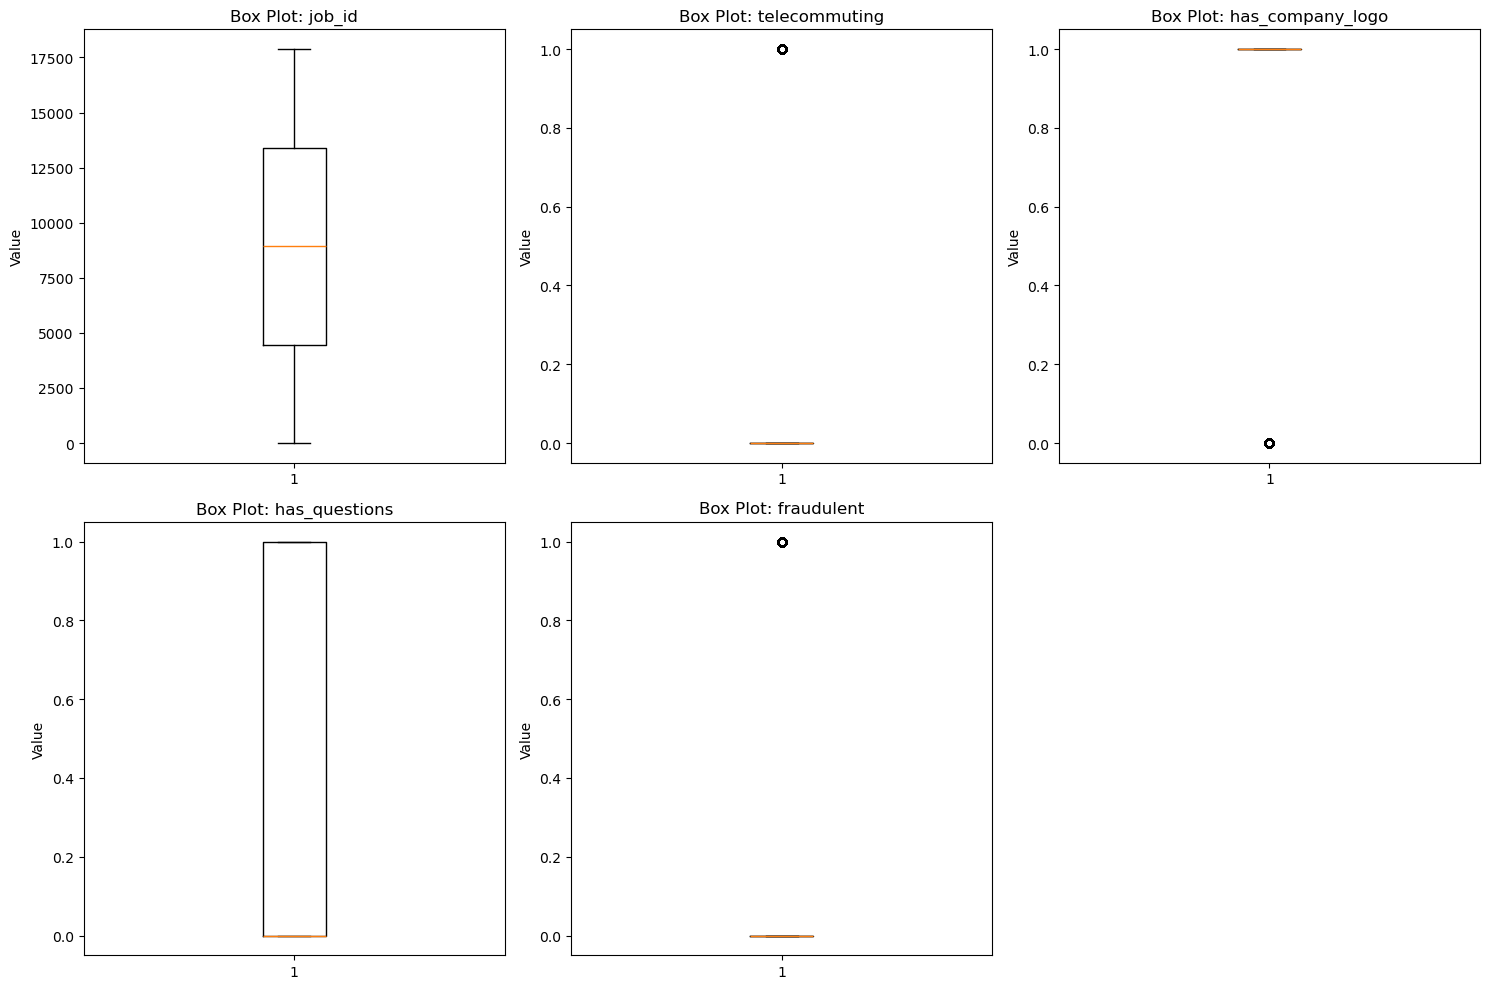


Box plots generated for 5 numeric columns


In [8]:
# Detect outliers using box plots
print("=" * 50)
print("OUTLIER DETECTION")
print("=" * 50)

numeric_cols = df.select_dtypes(include=[np.number]).columns

if len(numeric_cols) > 0:
    # Calculate number of rows needed for subplots
    n_cols = min(3, len(numeric_cols))
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Box Plot: {col}')
        axes[idx].set_ylabel('Value')
    
    # Hide empty subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nBox plots generated for {len(numeric_cols)} numeric columns")
else:
    print("\nNo numeric columns found for outlier detection")


In [9]:
# Export cleaned data
print("=" * 50)
print("EXPORT CLEANED DATA")
print("=" * 50)

# Generate output path
import os
base_name = os.path.splitext(os.path.basename(csv_path))[0]
output_dir = os.path.join(os.path.dirname(csv_path), '..', 'cleaned')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, f"{base_name}_cleaned.csv")

# Export to CSV
df.to_csv(output_path, index=False)

print(f"\nCleaned data exported successfully!")
print(f"Output file: {output_path}")
print(f"\nFinal dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


EXPORT CLEANED DATA

Cleaned data exported successfully!
Output file: D:\Gannon\4semester\jupyter\notebook-studio\app\ipynb\uploads\..\cleaned\1770406763233_fake_job_postings_cleaned.csv

Final dataset shape: (17880, 18)
Rows: 17880, Columns: 18
